# Customer Segmentation in a Small Medium Business - Clustering Approach
*Floriand Beshku -*
*2026*

### CUSTOMER SEGMENTATION ANALYSIS: Clustering Unsupervised Technique 

This project applies data science techniques to transform raw customer behavior data into clear, interpretable customer segments and actionable business insights. Using a dataset of 500 coffee shop customers, clustering algorithms were implemented to identify natural groupings of customers based on purchasing behavior, visit patterns, and in-store activity.

### Business Context:
Small and medium-sized businesses often rely on informal observation or intuition to understand their customers. While experience can be valuable, it frequently leads to broad assumptions and inconsistent marketing strategies. Without clear segmentation, businesses face several challenges:

* Promotions are sent to all customers instead of targeted groups
* Marketing budgets are spread inefficiently
* Businesses struggle to understand which customer behaviors drive revenue

Customer segmentation helps solve these problems by identifying distinct behavioral groups, allowing businesses to tailor marketing, operations, and customer experience strategies.

### Objective: 
Identify meaningful customer segments based on observable behavior and determine which behavioral characteristics differentiate those segments.

### Dataset Overview:
Volume: 500 customer records. Each record summarizes typical purchasing and visit behavior for a customer.

### Key Variables: 
Customer segmentation was based on behavioral metrics such as:

visits_per_month
avg_ticket_usd
avg_drinks_per_visit
avg_food_items_per_visit
pct_food_orders
avg_dwell_minutes
pct_mobile_orders
pct_dine_in
discount_redemption_rate
weekend_share_pct
avg_party_size
work_session_pct
These variables capture customer frequency, spending patterns, product mix, time spent in-store, and ordering preferences.


### Methodology Workflow

| Step | Phase | Key Task |
| :--- | :--- | :--- |
| **01** | **Preparation** | Data cleaning and standardization of behavioral variables |
| **02** | **Exploration** | Exploratory analysis and distribution review |
| **03** | **Modeling** | Hierarchical clustering to identify natural grouping structure |
| **04** | **Segmentation** | K-Means clustering to produce stable customer clusters |
| **05** | **Validation** | Comparison of clustering methods and cluster sizes |
| **06** | **Visualization** | PCA used to visualize cluster separation |
| **07** | **Interpretation** | Cluster profiling to translate results into business insights |


### Core Focus: Interpretability. 
While clustering algorithms identify statistical patterns in the data, the primary focus of this project is interpretable customer segmentation. Instead of producing complex models that are difficult to explain, the analysis emphasizes:

* Clear behavioral profiles for each customer segment
* Simple interpretation of how segments differ
* Direct translation of results into practical business strategies

This ensures that the segmentation results can be easily understood and applied by business managers, supporting better marketing decisions, improved customer experience, and more efficient operations.


In [3]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

pd.set_option("display.max_columns", None)


In [4]:
df = pd.read_csv("coffee_shop_customers.csv")
df.shape


(500, 20)

In [5]:
df.head()

,customer_id,segment_true,daypart_mode,daypart_code,favorite_drink,favorite_drink_code,favorite_food,favorite_food_code,visits_per_month,avg_ticket_usd,avg_drinks_per_visit,avg_food_items_per_visit,pct_food_orders,avg_dwell_minutes,pct_mobile_orders,pct_dine_in,discount_redemption_rate,weekend_share_pct,avg_party_size,work_session_pct
0,C0001,Morning Commuters (Grab & Go),Morning,1,Espresso,6,NaN,0,20,6.61,1.06,0.14,4.9,7,75.0,25.2,22.6,22.5,1.3,12.1
1,C0002,Morning Commuters (Grab & Go),Morning,1,Drip Coffee,1,NaN,0,13,5.21,0.92,0.22,27.0,2,50.6,10.3,2.7,18.0,1.1,3.1
2,C0003,Morning Commuters (Grab & Go),Morning,1,Americano,2,Pastry,1,22,4.07,0.96,0.16,5.2,9,36.4,24.0,20.3,10.5,1.3,3.8
3,C0004,Morning Commuters (Grab & Go),Morning,1,Drip Coffee,1,Pastry,1,23,6.47,0.83,0.00,0.0,7,54.0,9.3,25.4,15.6,1.0,2.1
4,C0005,Morning Commuters (Grab & Go),Morning,1,Latte,3,NaN,0,8,5.39,0.92,0.33,23.4,3,73.9,11.0,21.7,16.2,1.1,1.5


In [6]:
cols_for_clustering = [
    "visits_per_month",
    "avg_ticket_usd",
    "avg_drinks_per_visit",
    "avg_food_items_per_visit",
    "pct_food_orders",
    "avg_dwell_minutes",
    "pct_mobile_orders",
    "pct_dine_in",
    "discount_redemption_rate",
    "weekend_share_pct",
    "avg_party_size",
    "work_session_pct"
]

X = df[cols_for_clustering].copy()
X.head()


,visits_per_month,avg_ticket_usd,avg_drinks_per_visit,avg_food_items_per_visit,pct_food_orders,avg_dwell_minutes,pct_mobile_orders,pct_dine_in,discount_redemption_rate,weekend_share_pct,avg_party_size,work_session_pct
0,20,6.61,1.06,0.14,4.9,7,75.0,25.2,22.6,22.5,1.3,12.1
1,13,5.21,0.92,0.22,27.0,2,50.6,10.3,2.7,18.0,1.1,3.1
2,22,4.07,0.96,0.16,5.2,9,36.4,24.0,20.3,10.5,1.3,3.8
3,23,6.47,0.83,0.00,0.0,7,54.0,9.3,25.4,15.6,1.0,2.1
4,8,5.39,0.92,0.33,23.4,3,73.9,11.0,21.7,16.2,1.1,1.5


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=cols_for_clustering)
X_scaled.head()


,visits_per_month,avg_ticket_usd,avg_drinks_per_visit,avg_food_items_per_visit,pct_food_orders,avg_dwell_minutes,pct_mobile_orders,pct_dine_in,discount_redemption_rate,weekend_share_pct,avg_party_size,work_session_pct
0,1.611649,-0.893428,-0.536083,-0.914921,-1.252308,-0.700133,1.598078,-0.557007,0.033132,-0.463039,-0.168132,-0.316127
1,0.463517,-1.437723,-0.970661,-0.710504,-0.316935,-0.817219,0.543578,-1.054578,-1.106770,-0.702454,-0.608269,-0.686560
2,1.939686,-1.880934,-0.846496,-0.863817,-1.239611,-0.653298,-0.070107,-0.597079,-0.098616,-1.101478,-0.168132,-0.657749
3,2.103705,-0.947858,-1.250032,-1.272652,-1.459698,-0.700133,0.690516,-1.087972,0.193520,-0.830142,-0.828338,-0.727719
4,-0.356577,-1.367742,-0.970661,-0.429430,-0.469303,-0.793802,1.550539,-1.031202,-0.018422,-0.798220,-0.608269,-0.752415


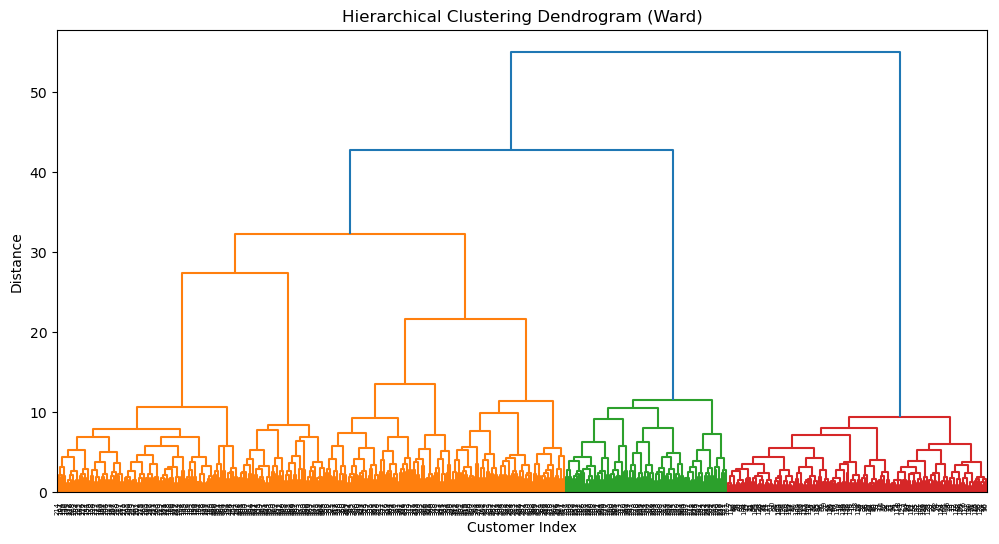

In [8]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linked, distance_sort="descending", show_leaf_counts=True)
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.xlabel("Customer Index")
plt.ylabel("Distance")
plt.show()


In [9]:
k = 3
clusters_h = fcluster(linked, t=k, criterion="maxclust")

df["hier_cluster"] = clusters_h
X_scaled["hier_cluster"] = clusters_h

df["hier_cluster"].value_counts().sort_index()


hier_cluster
1    140
2     87
3    273
Name: count, dtype: int64

In [10]:
X_scaled.groupby("hier_cluster")[cols_for_clustering].mean()


,visits_per_month,avg_ticket_usd,avg_drinks_per_visit,avg_food_items_per_visit,pct_food_orders,avg_dwell_minutes,pct_mobile_orders,pct_dine_in,discount_redemption_rate,weekend_share_pct,avg_party_size,work_session_pct
hier_cluster,,,,,,,,,,,,
1,1.250807,-1.062798,-0.584640,-0.861809,-0.841397,-0.717361,0.716385,-1.056439,-0.168336,-0.735858,-0.506095,-0.573225
2,-0.333954,0.187430,0.542512,-0.177139,-0.156442,1.701359,-0.913638,1.394206,-0.569575,-0.178860,-0.469145,1.907747
3,-0.535015,0.485294,0.126927,0.498404,0.481341,-0.174314,-0.076218,0.097456,0.267839,0.434362,0.409044,-0.314002


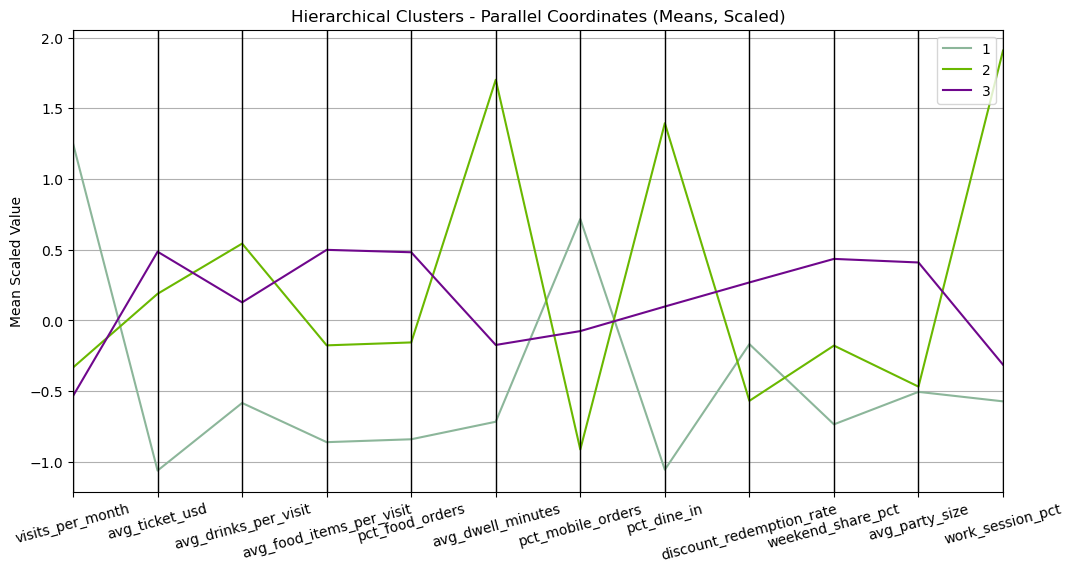

In [11]:
means_h = X_scaled.groupby("hier_cluster")[cols_for_clustering].mean().reset_index()

plt.figure(figsize=(12, 6))
parallel_coordinates(means_h, class_column="hier_cluster")
plt.title("Hierarchical Clusters - Parallel Coordinates (Means, Scaled)")
plt.ylabel("Mean Scaled Value")
plt.xticks(rotation=15)
plt.grid(True)
plt.show()


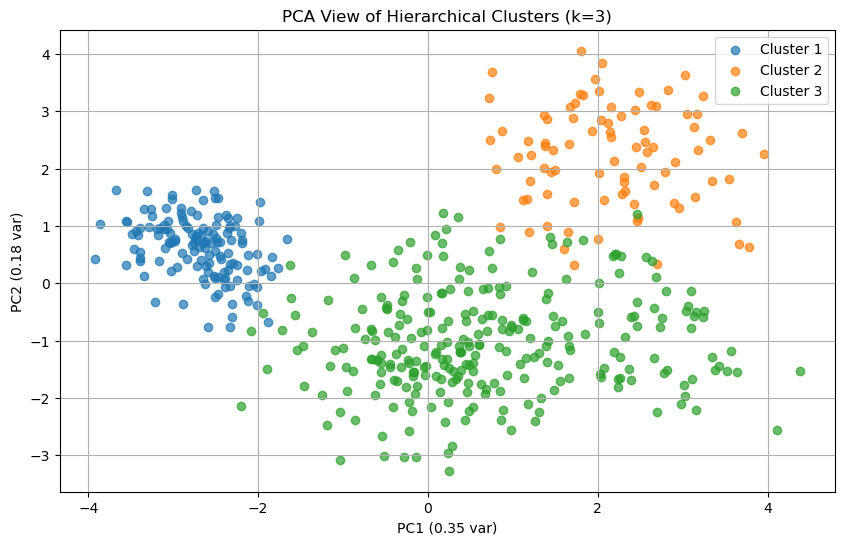

In [12]:
pca = PCA(n_components=2)
pc = pca.fit_transform(X_scaled[cols_for_clustering])

pc_df = pd.DataFrame(pc, columns=["PC1", "PC2"])
pc_df["hier_cluster"] = df["hier_cluster"].values

plt.figure(figsize=(10, 6))
for c in sorted(pc_df["hier_cluster"].unique()):
    tmp = pc_df[pc_df["hier_cluster"] == c]
    plt.scatter(tmp["PC1"], tmp["PC2"], label=f"Cluster {c}", alpha=0.7)

plt.title(f"PCA View of Hierarchical Clusters (k={k})")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2f} var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2f} var)")
plt.grid(True)
plt.legend()
plt.show()


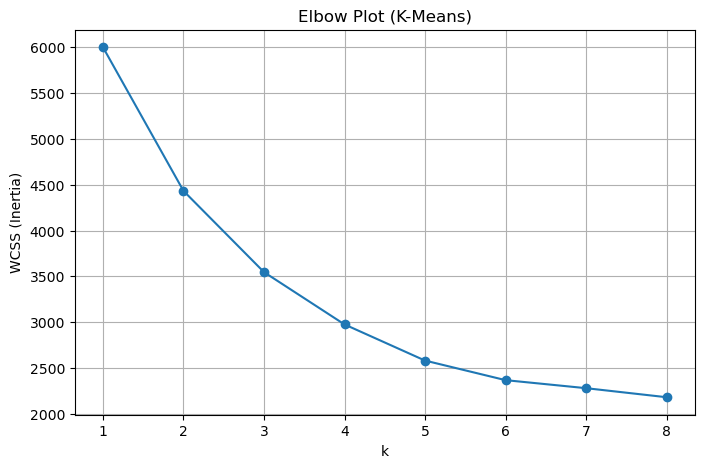

In [13]:
wcss = []
K = range(1, 9)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled[cols_for_clustering])
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K), wcss, marker="o")
plt.title("Elbow Plot (K-Means)")
plt.xlabel("k")
plt.ylabel("WCSS (Inertia)")
plt.grid(True)
plt.show()


In [14]:
k_km = 3
kmeans = KMeans(n_clusters=k_km, random_state=42, n_init=10)

df["kmeans_cluster"] = kmeans.fit_predict(X_scaled[cols_for_clustering])

df["kmeans_cluster"].value_counts().sort_index()


kmeans_cluster
0    263
1     83
2    154
Name: count, dtype: int64

In [15]:
# Centroids on scaled variables
centroids_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=cols_for_clustering)
centroids_scaled


,visits_per_month,avg_ticket_usd,avg_drinks_per_visit,avg_food_items_per_visit,pct_food_orders,avg_dwell_minutes,pct_mobile_orders,pct_dine_in,discount_redemption_rate,weekend_share_pct,avg_party_size,work_session_pct
0,-0.553025,0.526571,0.160989,0.550783,0.533467,-0.145328,-0.146255,0.157538,0.167558,0.442590,0.444378,-0.302089
1,-0.307174,0.101197,0.500247,-0.151742,-0.124741,1.753895,-0.923257,1.418515,-0.572396,-0.192728,-0.481001,2.005301
2,1.110007,-0.953816,-0.544549,-0.858839,-0.843821,-0.697091,0.747372,-1.033566,0.022345,-0.651980,-0.499664,-0.564873


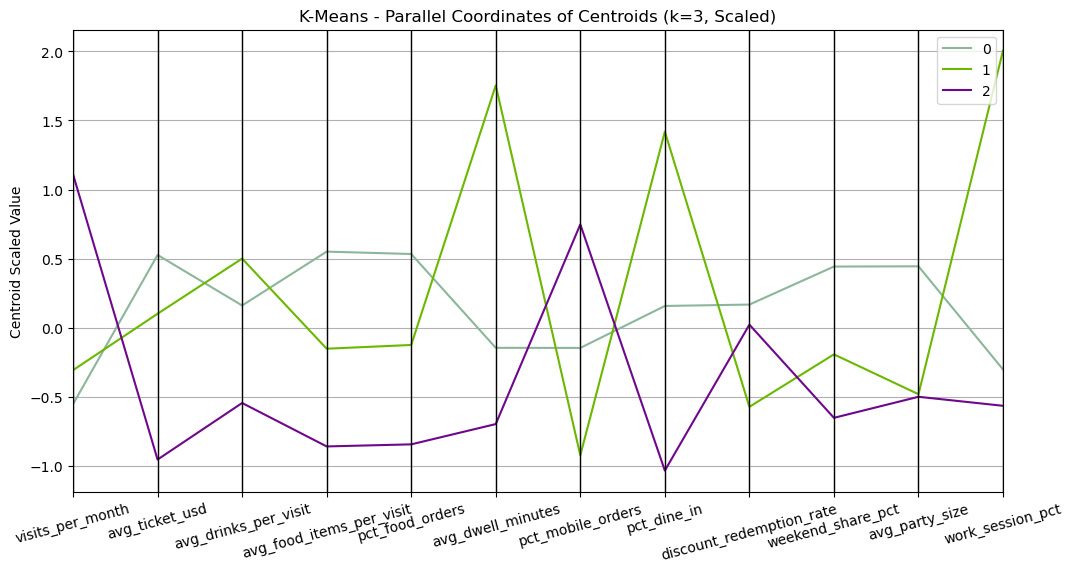

In [16]:
centroids_plot = centroids_scaled.copy()
centroids_plot["kmeans_cluster"] = centroids_plot.index

plt.figure(figsize=(12, 6))
parallel_coordinates(centroids_plot, class_column="kmeans_cluster")
plt.title(f"K-Means - Parallel Coordinates of Centroids (k={k_km}, Scaled)")
plt.ylabel("Centroid Scaled Value")
plt.xticks(rotation=15)
plt.grid(True)
plt.show()


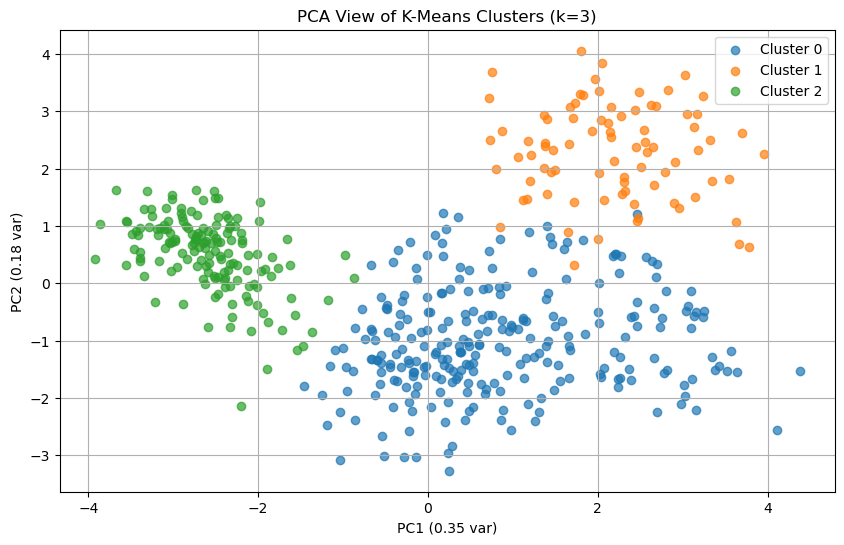

In [17]:
pca2 = PCA(n_components=2)
pc2 = pca2.fit_transform(X_scaled[cols_for_clustering])

pc2_df = pd.DataFrame(pc2, columns=["PC1", "PC2"])
pc2_df["kmeans_cluster"] = df["kmeans_cluster"].values

plt.figure(figsize=(10, 6))
for c in sorted(pc2_df["kmeans_cluster"].unique()):
    tmp = pc2_df[pc2_df["kmeans_cluster"] == c]
    plt.scatter(tmp["PC1"], tmp["PC2"], label=f"Cluster {c}", alpha=0.7)

plt.title(f"PCA View of K-Means Clusters (k={k_km})")
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.2f} var)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.2f} var)")
plt.grid(True)
plt.legend()
plt.show()
